In [1]:
# import modules
import scipy.integrate
import pyfabm
from matplotlib.pyplot import figure
import pandas as pd
import xarray as xr
from numpy import zeros

# define function to calculate derivative / growth rates
def dy(t, y):
    model.state[:] = y
    return model.getRates(t)

# set-up of the model
model = pyfabm.Model("./fabm.yaml")

# set-up of external dependencies
model.cell_thickness = 1.0  # cell thickness in m, used by getRates to scale surface and bottom fluxes
model.dependencies["seeding_rate"].value=0.0
model.dependencies["harvest_ratio"].value=0.0
model.dependencies["temperature"].value=20.0
model.dependencies["practical_salinity"].value=33.0
model.dependencies["current_speed"].value=1.0
model.dependencies["harvest_ratio"].value=0.0
model.dependencies["air_exposure"].value=0.0
model.dependencies["number_of_days_since_start_of_the_year"].value=0.0



# checkl that model is set up correctly
assert model.start(), f"Model failed to start: {pyfabm.getError()}"


# integrate the model
# result dimensions are time x variables
# variables are:
# shell energy
# dry soft tissue energy
# aging
# individuals in size class 1
# individuals in size class 2
# individuals in size class 3


Initializing Oyster...
   model type: shellsim_base
   initialization succeeded.
Initializing Chl1...
   model type: shellsim/prey
   initialization succeeded.
Initializing POC1...
   model type: shellsim/prey
   initialization succeeded.
Initializing POM1...
   model type: shellsim/prey
   initialization succeeded.
Initializing TPM1...
   model type: shellsim/prey
   initialization succeeded.
Initializing O2...
   model type: bb/passive
   initialization succeeded.


In [2]:

# import modules
import scipy.integrate
import pyfabm
from matplotlib.pyplot import figure
import pandas as pd
import xarray as xr
from numpy import zeros
import sys 
from contextlib import redirect_stdout # <-- Import this


In [3]:

# define function to calculate derivative / growth rates
def dy(t, y):
    model.state[:] = y
    return model.getRates(t)

# --- START REDIRECTION BLOCK ---
# We will open the log file and redirect all stdout within this 'with' block
with open('run.log', 'w') as log_file:
    with redirect_stdout(log_file):
        
        # set-up of the model
        # The output from pyfabm.Model will now go to 'run.log'
        model = pyfabm.Model("./fabm.yaml")

        # set-up of external dependencies
        model.cell_thickness = 1.0  # cell thickness in m, used by getRates to scale surface and bottom fluxes
        model.dependencies["seeding_rate"].value=0.0
        model.dependencies["harvest_ratio"].value=0.0
        model.dependencies["temperature"].value=20.0
        model.dependencies["practical_salinity"].value=33.0
        model.dependencies["current_speed"].value=1.0
        model.dependencies["harvest_ratio"].value=0.0
        model.dependencies["air_exposure"].value=0.0
        model.dependencies["number_of_days_since_start_of_the_year"].value=0.0

        # checkl that model is set up correctly
        # The output from model.start() (if any) will also go to 'run.log'
        assert model.start(), f"Model failed to start: {pyfabm.getError()}"

# --- END REDIRECTION BLOCK ---
# Execution continues here. Standard stdout printing is restored.

# You can optionally print a message to confirm it worked
print("FABM model initialization output has been redirected to 'run.log'.")

FABM model initialization output has been redirected to 'run.log'.


In [4]:
# load inputs - these would be the EO derived information, they can be at different temporal resolution
input_T_timeseries=xr.open_dataset('T_daily_timeseries.nc')
input_S_timeseries=xr.open_dataset('S_daily_timeseries.nc')
input_Chl_timeseries=xr.open_dataset('Chl_monthly_timeseries.nc')
input_POC_timeseries=xr.open_dataset('POC_monthly_timeseries.nc')
input_POM_timeseries=xr.open_dataset('POM_monthly_timeseries.nc')
input_TPM_timeseries=xr.open_dataset('TPM_monthly_timeseries.nc')


#define period of integration - timestep = 1day
start='1-1-2010'
end='31-12-2010'
time_horizon=pd.date_range(start=start,end=end,freq='1d')

# make sure that all timeseries have the same (daily) resolution.
T_timeseries=input_T_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
S_timeseries=input_S_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
Chl_timeseries=input_Chl_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
POC_timeseries=input_POC_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
POM_timeseries=input_POM_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
TPM_timeseries=input_TPM_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})

# initialise array with outputs
outputs=zeros((11,time_horizon.size))
# output 0:  Soft tissue energy
# output 1:  Shell energy
# output 2:  aging
# output 3:  C1
# output 4:  C2
# output 5:  C3
# output 6:  Chl
# output 7:  POC
# output 8:  POM
# output 9:  TPM
# output 10: O2

# daily integration over the temporal horizon
for nd,day in enumerate(time_horizon):
    # set the right environmental variables
    model.dependencies["temperature"].value=T_timeseries.temperature.sel(time=day,method='nearest').values
    model.dependencies["practical_salinity"].value=S_timeseries.salinity.sel(time=day,method='nearest').values

    # set the right food variables
    model.findStateVariable('Chl1/Chl').value=Chl_timeseries.Chl.sel(time=day,method='nearest').values
    model.findStateVariable('POC1/POC').value=POC_timeseries.POC.sel(time=day,method='nearest').values
    model.findStateVariable('POM1/POM').value=POM_timeseries.POM.sel(time=day,method='nearest').values
    model.findStateVariable('TPM1/TPM').value=TPM_timeseries.TPM.sel(time=day,method='nearest').values

    # calculate growth rates
    state_rates=model.getRates()

    # perform forward Euler integration
    model.state[:]+=state_rates*86400.

    # save the integrated values in the outputs
    outputs[:,nd]=model.state[:]



print(len(outputs))


11


Text(0.5, 1.0, 'Oyster - Soft Tissue Energy')

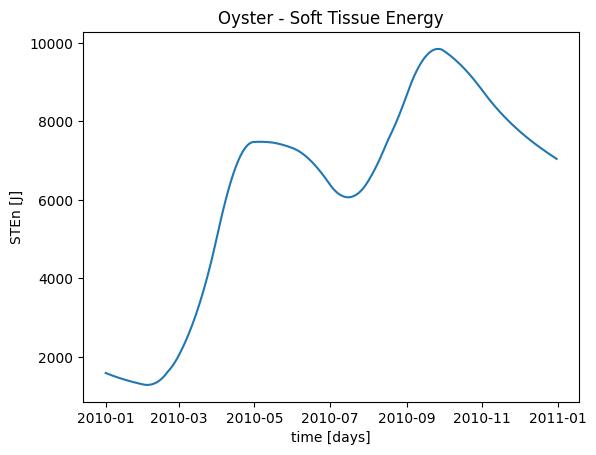

In [5]:
fig=figure()
ax=fig.add_subplot()
ax.plot(time_horizon,outputs[0,:],label='Soft Tissue Energy')
ax.set_xlabel('time [days]')
ax.set_ylabel('STEn [J]')
ax.set_title('Oyster - Soft Tissue Energy')